# Simple NetworkX visualization of connectivity routes of nodes

Óscar

In [47]:
import pandas as pd
import networkx as nx
import numpy as np
import re
import matplotlib.pyplot as plt

In [48]:
# --- Helper: convert "A'B" → minutes ---
def time_to_minutes(val):
    if pd.isna(val):
        return None
    
    if isinstance(val, str):
        val = val.strip()
        
        # Self-loop marker
        if val.upper() == "X":
            return 0
        
        # Match format A'B
        match = re.match(r"(\d+)'(\d+)", val)
        if match:
            hours = int(match.group(1))
            minutes = int(match.group(2))
            return 60 * hours + minutes
    
    # Optional: already numeric
    if isinstance(val, (int, float)):
        return float(val)
    
    return None

def test_time_to_minutes():
    """
    unit tests for function time_to_minutes
    """
    # Standard cases
    assert time_to_minutes("1'30") == 90
    assert time_to_minutes("0'45") == 45
    assert time_to_minutes("10'00") == 600

    # Edge cases
    assert time_to_minutes("X") == 0
    assert time_to_minutes(" x ") == 0  # whitespace + case

    # Numeric passthrough
    assert time_to_minutes(15) == 15.0
    assert time_to_minutes(12.5) == 12.5

    # NaN handling
    assert time_to_minutes(np.nan) is None

    # Invalid formats → should return None
    assert time_to_minutes("abc") is None
    assert time_to_minutes("1:30") is None
    assert time_to_minutes("") is None

    assert time_to_minutes(np.nan) is None

    print("All tests passed!")

# Run
test_time_to_minutes()

All tests passed!


In [49]:
data_arr = pd.read_excel("place_map_v1.xlsx", header=None)
data_arr

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,X,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,4'50,NaN,NaN,NaN,4'35,NaN
1,NaN,X,NaN,NaN,NaN,NaN,NaN,4'20,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,X,1'25,0'45,NaN,NaN,0,0,NaN,...,3'10,0,NaN,NaN,0,NaN,NaN,NaN,NaN,1'00
3,NaN,NaN,NaN,X,1'30,NaN,0,0,0,NaN,...,NaN,0,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,X,NaN,NaN,0,0,NaN,...,NaN,0,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,X,NaN,NaN,2'25,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,X,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,X,NaN,NaN,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,X,NaN,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,X,...,NaN,NaN,NaN,NaN,1'00,1'50,NaN,NaN,NaN,NaN


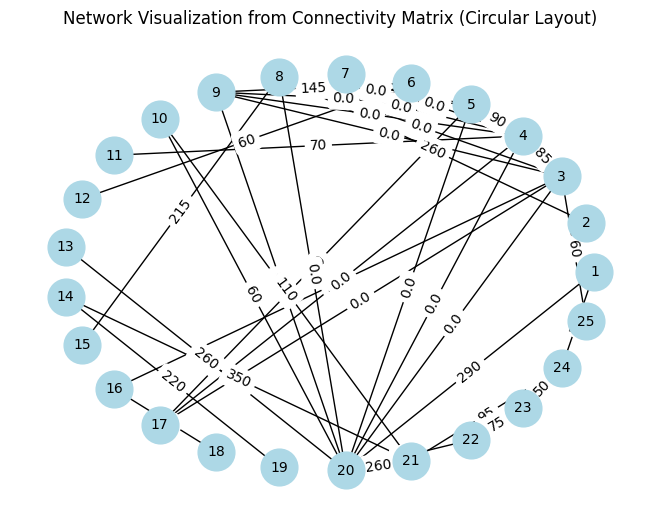

In [56]:
# Example connectivity matrix (replace with your actual matrix)
# NaN or 'X' means no edge
connectivity_matrix = np.array(data_arr, dtype=object)

# Create a graph
G = nx.Graph()

# Add nodes (assuming nodes are labeled 0, 1, 2, ...)
num_nodes = connectivity_matrix.shape[0]
G.add_nodes_from(range(1,num_nodes+1))

# Add edges, ignoring NaN or 'X'
for i in range(num_nodes):
    for j in range(i + 1, num_nodes):
        weight = connectivity_matrix[i, j]
        weight = time_to_minutes(weight)
        # Check if the weight is a number and not NaN
        if isinstance(weight, (int, float)) and weight!=None: #
            #print(weight)
            G.add_edge(i+1, j+1, weight=weight)

# Draw the graph with circular layout
pos = nx.circular_layout(G)  # Use circular_layout for nodes on a circle
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=700, font_size=10)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Network Visualization from Connectivity Matrix (Circular Layout)")
plt.show()